--- Data Summary ---
Total Charged Off Loans: 268559
Average Loan Amount: $15565.06
Average Recovery: $1209.46
Average Collection Fee: $201.53

Constraint Identification:
Loans with $0.00 Recovery: 83875 (31.23%)


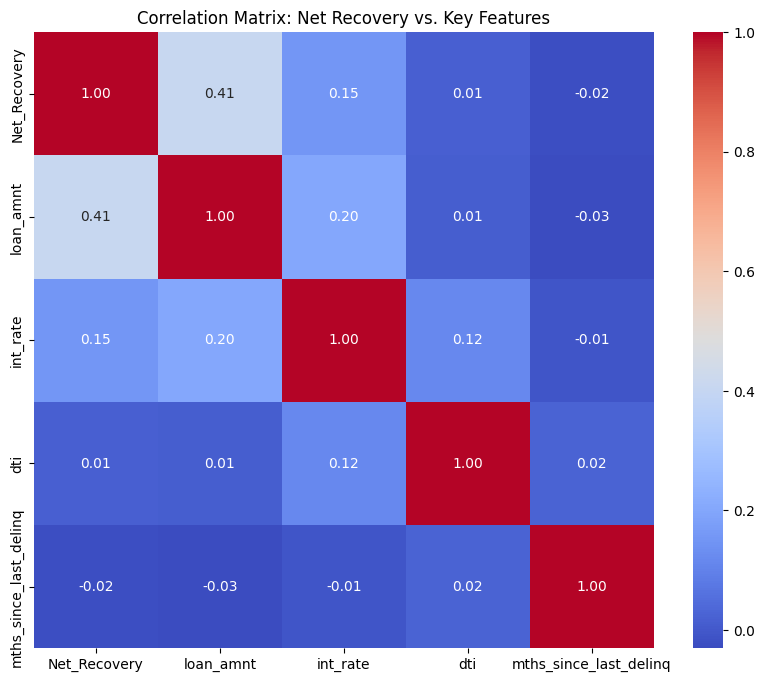

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data (Replace with your actual file path)
df = pd.read_csv('/content/recovery_analysis_data.csv')
df_charged_off = df[df['loan_status'] == 'Charged Off'].copy()

# --- FOR REPORT REQUIREMENT #4 (Summary Stats) ---
print("--- Data Summary ---")
print(f"Total Charged Off Loans: {len(df_charged_off)}")
print(f"Average Loan Amount: ${df_charged_off['loan_amnt'].mean():.2f}")
print(f"Average Recovery: ${df_charged_off['recoveries'].mean():.2f}")
print(f"Average Collection Fee: ${df_charged_off['collection_recovery_fee'].mean():.2f}")

# --- FOR REPORT REQUIREMENT #6 (Abnormal Data/Constraints) ---
zero_recovery_count = len(df_charged_off[df_charged_off['recoveries'] == 0])
zero_pct = (zero_recovery_count / len(df_charged_off)) * 100
print(f"\nConstraint Identification:")
print(f"Loans with $0.00 Recovery: {zero_recovery_count} ({zero_pct:.2f}%)")
# This number (likely >40%) justifies the "Zero-Inflated" section in your Lit Review.

# --- FOR REPORT REQUIREMENT #4 (Correlation) ---
# Create Net Recovery for accurate correlation
df_charged_off['Net_Recovery'] = df_charged_off['recoveries'] - df_charged_off['collection_recovery_fee']

# Select relevant numeric columns
cols = ['Net_Recovery', 'loan_amnt', 'int_rate', 'dti', 'mths_since_last_delinq']
corr = df_charged_off[cols].corr()

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Net Recovery vs. Key Features')
plt.show()